# Plus sur les fonctions

Nous avons vu dans ce chapitre 10 le concept incontournable que représentent
les fonctions. Nous avons également introduit la notion de variables locales et globales.
Dans ce chapitre, nous allons aller un peu plus loin sur la visibilité de ces variables dans et hors des fonctions, et
aussi voir ce qui se passe lorsque ces variables sont des listes. Attention, la plupart des lignes de code ci-dessous sont
données à titre d’exemple pour bien comprendre ce qui se passe, mais nombre d’entre elles sont des aberrations en terme
de programmation. Nous ferons un récapitulatif des bonnes pratiques à la fin du chapitre. Enfin, nous vous conseillons
de tester tous les exemples ci-dessous avec le site Python Tutor 
afin de suivre l’état des variables lors de l’exécution des
exemples.

### Appel d’une fonction dans une fonction
Dans le chapitre 10, nous avons vu des fonctions qui étaient appelées depuis le programme principal. Il est en fait
possible d’appeler une fonction depuis une autre fonction. Et plus généralement, on peut appeler une fonction de n’importe
où à partir du moment où elle est visible par Python (c’est-à-dire chargée dans la mémoire). Observez cet exemple :


In [16]:
# Définition des fonctions.
def est_pair(x):
    if x % 2 == 0:
        return True
    else:
        return False

def calc_somme_nb_pairs(debut, fin):
    somme = 0
    for nombre in range(debut, fin + 1):
        if est_pair(nombre):
            somme += nombre
    return somme   

# Programme principal.
somme = calc_somme_nb_pairs(1, 5)
print(f"La somme des nombres pairs de 1 à 5 est {somme}")

La somme des nombres pairs de 1 à 5 est 6


Nous appelons la fonction calc_somme_nb_pairs() depuis le programme principal, puis à l’intérieur de celle-ci nous appelons l’autre fonction est_pair().

### Fonctions récursives

Une fonction récursive est une fonction qui s’appelle elle-même. Les fonctions récursives permettent d’obtenir une
efficacité redoutable dans la résolution de certains algorithmes, comme le tri rapide [lien](https://fr.wikipedia.org/wiki/Tri_rapide)
(en anglais, quicksort).
Oublions la recherche d’efficacité pour l’instant et concentrons-nous sur l’exemple de la fonction mathématique
factorielle. Nous vous rappelons que la factorielle s’écrit avec un ! et se définit de la manière suivante :  
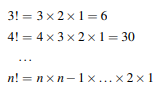

Voici le code Python avec une fonction récursive :

In [17]:
def calc_factorielle(nb):
    if nb == 1:
        return 1
    else:
        return nb * calc_factorielle(nb - 1)
# Programme principal.
print(calc_factorielle(4))

24


Pas si facile à comprendre, n’est-ce pas ? À nouveau, Python Tutor peut nous aider pour visualiser ce qui se passe (nous vous conseillons bien sûr de tester vous-même cet exemple).

Lorsqu’on appelle la fonction calc_factorielle(4), la variable locale nb prend la valeur 4. La fonction s’appelle ensuite elle-même avec 3, puis 2, puis 1.

À l’appel avec nb == 1, la condition est vraie et return 1 est exécuté. C’est le point de départ du « dépilement » :

- calc_factorielle(1) renvoie 1

- calc_factorielle(2) calcule 2 × 1 = 2

- calc_factorielle(3) calcule 3 × 2 = 6

- calc_factorielle(4) calcule 4 × 6 = 24

Chaque appel attend la valeur renvoyée par l’appel suivant, ce qui forme une pile d’exécution. Une fois arrivé au cas de base (nb == 1), les résultats se propagent en remontant la pile, jusqu’au programme principal.

### Portée des variables
Il est très important lorsque l’on manipule des fonctions de connaître la portée des variables (scope en anglais),
c’est-à-dire savoir là où elles sont visibles. On a vu que les variables créées au sein d’une fonction ne sont pas visibles à
l’extérieur de celle-ci car elles étaient locales à la fonction. Observez le code suivant :

In [19]:
def ma_fonction():
    x = 2
    print(f"x vaut {x} dans la fonction")

ma_fonction()
print(x)


x vaut 2 dans la fonction


NameError: name 'x' is not defined

Lorsque Python exécute le code de la fonction, il connaît le contenu de la variable x. Par contre, de retour dans le
module principal (dans ce cas, il s’agit de l’interpréteur Python), il ne la connaît plus, d’où le message d’erreur.
De même, une variable passée en argument est considérée comme locale lorsqu’on arrive dans la fonction :

In [20]:
def ma_fonction(x):
    print(f"x vaut {x} dans la fonction")

ma_fonction(x=2)
print(x)

x vaut 2 dans la fonction


NameError: name 'x' is not defined

Lorsqu’une variable est déclarée dans le programme principal, elle est visible dans celui-ci ainsi que dans toutes les
fonctions. On a vu qu’on parlait de variable globale :

In [21]:
def ma_fonction():
    print(x)

x = 3
ma_fonction()   # Affiche 3
print(x)        # Affiche 3

3
3


Dans ce cas, la variable x est visible dans le module principal et dans toutes les fonctions du module. Toutefois,
Python ne permet pas la modification d’une variable globale dans une fonction :

In [22]:
def ma_fonction():
    x = x + 1
    return x

x = 1
print(ma_fonction())


UnboundLocalError: cannot access local variable 'x' where it is not associated with a value

L’erreur renvoyée montre que Python pense que x est une variable locale qui n’a pas été encore assignée. Si on veut
vraiment modifier une variable globale dans une fonction, il faut utiliser le mot-clé global :

In [ ]:
def ma_fonction():
    global x
    x = x + 1

x = 1
ma_fonction()
x
# Dans ce dernier cas, le mot-clé global a forcé la variable x à être globale plutôt que locale au sein de la fonction.

2

### Portée des listes
Attention : Les exemples de cette partie représentent des absurdités en termes de programmation. Ils sont donnés à titre indicatif
pour comprendre ce qui se passe, mais il ne faut surtout pas s’en inspirer!


Soyez extrêmement attentifs avec les types modifiables (tels que les listes) car vous pouvez les changer au sein d’une
fonction :

In [24]:
def ma_fonction():
    liste1[1] = -127

liste1 = [1, 2, 3]
ma_fonction()
print(liste1)

[1, -127, 3]


De même, si vous passez une liste en argument, elle est modifiable au sein de la fonction :

In [25]:
def ma_fonction(liste_tmp):
    liste_tmp[1] = -127

liste1 = [1, 2, 3]
ma_fonction(liste1)
print(liste1)

[1, -127, 3]


On voit très clairement que la variable liste1 passée en argument lors de l’appel de la fonction d’une part, et la
variable locale liste_tmp au sein de la fonction d’autre part, pointent vers le même objet dans la mémoire. Ainsi,
si on modifie liste_tmp, on modifie aussi liste1. C’est exactement le même mécanisme que pour la copie de listes
(cf. rubrique 11.4 Copie de listes du chapitre 12 Plus sur les listes).
Si vous voulez éviter les problèmes de modification malencontreuse d’une liste dans une fonction, utilisez des tuples (ils
ont présentés dans le chapitre 8 Dictionnaires et tuples), Python renverra une erreur car ces derniers sont non modifiables.
Une autre solution pour éviter la modification d’une liste, lorsqu’elle est passée comme argument à une fonction, est
de la passer explicitement (comme nous l’avons fait pour la copie de liste) afin qu’elle reste intacte dans le programme
principal :

In [27]:
def ma_fonction(liste_tmp):
    liste_tmp[1] = -15

liste1 = [1, 2, 3]

ma_fonction(liste1.copy())
liste1

[1, 2, 3]

### Règle LGI
Lorsque Python rencontre une variable, il va traiter la résolution de son nom avec des priorités particulières. D’abord
il va regarder si la variable est locale, puis si elle n’existe pas localement, il vérifiera si elle est globale et enfin si elle
n’est pas globale, il testera si elle est interne (par exemple la fonction len() est considérée comme une fonction interne
à Python, elle existe à chaque fois que vous lancez Python). On appelle cela la règle LGI pour locale, globale, interne.
En voici un exemple :

In [28]:
def ma_fonction():
    x = 4
    print(f"Dans la fonction x vaut {x}")

x = -15
ma_fonction()
print(f"Dans le module principal x vaut {x}")

Dans la fonction x vaut 4
Dans le module principal x vaut -15


Dans la fonction, x a pris la valeur qui lui était définie localement en priorité sur la valeur définie dans le module
principal.  
Conseil : Même si Python accepte qu’une variable ait le même nom que ses propres fonctions ou variables internes, évitez
d’utiliser de tels noms, car ceci rendra votre code confus!  
De manière générale, la règle LGI découle de la manière dont Python gère ce que l’on appelle « les espaces de noms ».
C’est cette gestion qui définit la portée (visibilité) de chaque variable.

### Recommandations
- ##### Évitez les variables globales  
Dans ce chapitre nous avons joué avec les fonctions (et les listes) afin de vous montrer comment Python réagissait.
Toutefois, notez bien que l’utilisation de variables globales est à bannir définitivement de votre pratique de la
programmation.  
Parfois on veut faire vite et on crée une variable globale visible partout dans le programme (donc dans toutes les
fonctions), car « Ça va plus vite, c’est plus simple ». C’est un très mauvais calcul, ne serait-ce que parce que vos fonctions
ne seront pas réutilisables dans un autre contexte si elles utilisent des variables globales! Ensuite, arriverez-vous à vous
relire dans six mois? Quelqu’un d’autre pourrait-il comprendre votre programme? Il existe de nombreuses autres raisons [lien](https://wiki.c2.com/?GlobalVariablesAreBad)
que nous ne développerons pas ici, mais libre à vous de consulter de la documentation externe.
Heureusement, Python est orienté objet et permet « d’encapsuler » des variables dans des objets et de s’affranchir
définitivement des variables globales (nous verrons cela dans le chapitre Avoir la classe avec les objets). En attendant,
et si vous ne souhaitez pas aller plus loin sur les notions d’objet (on peut tout à fait « pythonner » sans cela), retenez la
chose suivante sur les fonctions et les variables globales :  
Conseil : Plutôt que d’utiliser des variables globales, passez vos variables explicitement aux fonctions comme des argument(s).

- ##### Modification d’une liste dans une fonction  
Concernant les fonctions qui modifient une liste, nous vous conseillons de l’indiquer clairement dans votre code. Pour
cela, faites en sorte que la fonction renvoie la liste modifiée et de récupérer cette liste renvoyée dans une variable portant
le même nom. Par exemple :

In [29]:
def ajoute_un(liste):
    for indice in range(len(liste)):
        liste[indice] += 1
    return liste

# Programme principal
liste_notes = [10, 8, 16, 7, 15]
liste_notes = ajoute_un(liste_notes)
print(liste_notes)

[11, 9, 17, 8, 16]


La ligne 8 indique que la liste liste_notes passée à la fonction est écrasée par la liste renvoyée par la fonction.
Le code suivant produirait la même sortie :

In [30]:
def ajoute_un(liste):
    for indice in range(len(liste)):
        liste[indice] += 1

# Programme principal
liste_notes = [10, 8, 16, 7, 15]
ajoute_un(liste_notes)
print(liste_notes)

[11, 9, 17, 8, 16]


Cela reste toutefois moins intuitif, car il n’est pas évident de comprendre que la liste est modifiée dans la fonction
en lisant la ligne 7. Dans un tel cas, il serait essentiel d’indiquer dans la documentation de la fonction que la liste est
modifiée « sur place » dans la fonction.  
Conseil : Pour les raisons évoquées ci-dessus, nous vous conseillons de privilégier la première version :
```py
liste_notes = ajoute_un(liste_notes)

### Conclusion
Vous connaissez maintenant les fonctions sous tous leurs angles. Comme indiqué en introduction du chapitre 10, elles
sont incontournables et tout programmeur se doit de les maîtriser. Voici les derniers conseils que nous pouvons vous
donner :
- Lorsque vous débutez un nouveau projet de programmation, posez-vous la question : « Comment pourrais-je
décomposer en blocs chaque tâche à effectuer, chaque bloc pouvant être une fonction ? ». Et n’oubliez pas que si
une fonction s’avère trop complexe, vous pouvez la décomposer en d’autres fonctions.
- Au risque de nous répéter, forcez-vous à utiliser des fonctions en permanence. Pratiquez, pratiquez… et pratiquez
encore!
